
# Hybrid Recommendation System — Laptop E-commerce Platform
### Đồ án: Nền tảng TMĐT bán sản phẩm công nghệ tích hợp Chatbot AI (RAG) + Recommendation System (Deep Learning)

**Mục tiêu notebook này:**
1. Xây dựng & huấn luyện 5 nhóm mô hình gợi ý trên nền tảng Kaggle: **User-CF, Item-CF, Matrix Factorization, Content-Based, Hybrid** (+ mở rộng **Neural CF** và **Two-Tower**)
2. Kiểm thử kỹ thuật: CF có huấn luyện được không, Hybrid có kết hợp đúng không, pipeline có xử lý cold-start không
3. So sánh các thuật toán trong môi trường mô phỏng bằng **Precision@K, Recall@K, NDCG@K**

**Lưu ý quan trọng về dữ liệu (đọc trước khi chạy):**

File `products_full.json` bạn cung cấp là **catalog sản phẩm thật** (91 laptop, đầy đủ specs, giá, brand, category, và embedding nội dung 384 chiều đã sinh sẵn bằng `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`). Đây là dữ liệu **rất tốt cho Content-Based Filtering** — dùng trực tiếp được.

Tuy nhiên, catalog này **không có log hành vi người dùng** (view/cart/purchase), mà đây là dữ liệu bắt buộc để huấn luyện User-CF, Item-CF, Matrix Factorization, NCF, Two-Tower. Vì hệ thống thật của bạn (Next.js + Express + MongoDB) mới ở giai đoạn đồ án nên gần như chắc chắn chưa có đủ log thật (hàng nghìn tương tác) để train.

**Giải pháp dùng trong notebook này** (cách làm chuẩn khi báo cáo khoa học thiếu dữ liệu production):
- Sinh **dữ liệu tương tác mô phỏng (synthetic interaction log)** dựa trên *persona người dùng* gắn với thuộc tính sản phẩm thật (brand, category, giá, cấu hình) — không phải random thuần túy, mà có "sở thích" hợp lý để mô phỏng hành vi thực.
- Toàn bộ pipeline (feature engineering, train/test split, model, metric) viết tổng quát — khi hệ thống thật có log MongoDB (`views`, `cart_items`, `orders`), bạn chỉ cần thay Section 3 bằng truy vấn thật, phần còn lại **giữ nguyên**.
- Trong báo cáo, bạn trình bày rõ mục "Chiến lược dữ liệu": vì sao dùng dữ liệu mô phỏng, cách sinh có kiểm soát ra sao, và cam kết pipeline tương thích dữ liệu thật.

Nếu bạn **đã có log thực** (export từ MongoDB), bỏ qua Section 3 và nạp trực tiếp DataFrame `interactions` theo đúng schema mô tả bên dưới.


## 0. Cài đặt & Import thư viện

In [2]:

# Trên Kaggle: bật GPU (Settings > Accelerator > GPU T4) để train NCF / Two-Tower nhanh hơn
import numpy as np
import pandas as pd
import json, re, math, random
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu



## 1. Nạp dữ liệu sản phẩm (Content-Based source of truth)

Upload `products_full.json` vào Kaggle dataset (Add Data), rồi sửa `DATA_PATH` bên dưới cho đúng path
(thường là `/kaggle/input/<ten-dataset>/products_full.json`).


In [3]:

DATA_PATH = "/kaggle/input/datasets/phmvitqun/products-full/products_full.json"  # <-- sửa lại đúng path trên Kaggle

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

products = raw["data"] if isinstance(raw, dict) and "data" in raw else raw
print("Số sản phẩm:", len(products))
products[0].keys()


Số sản phẩm: 91


dict_keys(['_id', 'id', 'title', 'description', 'images', 'price', 'specifications', 'faqs', 'series', 'part_number', 'category_id', 'name', 'sku', 'brand_id', 'color_id', 'embedding', 'recommendation_metadata', 'updatedAt', 'document_chunks', 'embedding_metadata', 'rag_embedding', 'stock'])

In [4]:

def parse_ram_gb(s):
    if not s: return np.nan
    m = re.search(r'(\d+)\s*GB', s.upper())
    return float(m.group(1)) if m else np.nan

def parse_storage_gb(s):
    if not s: return np.nan
    s_up = s.upper()
    m_tb = re.search(r'(\d+(\.\d+)?)\s*TB', s_up)
    if m_tb: return float(m_tb.group(1)) * 1024
    m_gb = re.search(r'(\d+)\s*GB', s_up)
    return float(m_gb.group(1)) if m_gb else np.nan

def has_dedicated_gpu(s):
    if not s: return 0
    s_low = s.lower()
    for kw in ["rtx", "gtx", "geforce", "radeon rx", "arc a", "quadro"]:
        if kw in s_low:
            return 1
    return 0

def parse_cpu_tier(s):
    if not s: return "unknown"
    s_low = s.lower()
    if "i9" in s_low or "ultra 9" in s_low or "ryzen 9" in s_low: return "tier5_flagship"
    if "i7" in s_low or "ultra 7" in s_low or "ryzen 7" in s_low: return "tier4_high"
    if "i5" in s_low or "ultra 5" in s_low or "ryzen 5" in s_low: return "tier3_mid"
    if "i3" in s_low or "ryzen 3" in s_low: return "tier2_entry"
    return "tier1_other"

rows = []
for p in products:
    spec = p.get("specifications", {}) or {}
    cats = p.get("category_id") or []
    cat_name = cats[0]["name"] if cats else "unknown"
    brand_name = (p.get("brand_id") or {}).get("name", "unknown")
    rows.append({
        "item_id": p["id"],
        "title": p["title"],
        "price": p["price"],
        "brand": brand_name,
        "category": cat_name,
        "cpu_raw": spec.get("cpu", ""),
        "gpu_raw": spec.get("gpu", ""),
        "ram_gb": parse_ram_gb(spec.get("ram", "")),
        "storage_gb": parse_storage_gb(spec.get("storage", "")),
        "cpu_tier": parse_cpu_tier(spec.get("cpu", "")),
        "has_dgpu": has_dedicated_gpu(spec.get("gpu", "")),
        "embedding": p.get("embedding"),   # 384-dim text embedding có sẵn (dùng cho content-based & RAG)
        "stock": p.get("stock", 0),
    })

items_df = pd.DataFrame(rows)
items_df["ram_gb"] = items_df["ram_gb"].fillna(items_df["ram_gb"].median())
items_df["storage_gb"] = items_df["storage_gb"].fillna(items_df["storage_gb"].median())
items_df.head()


,item_id,title,price,brand,category,cpu_raw,gpu_raw,ram_gb,storage_gb,cpu_tier,has_dgpu,embedding,stock
0,6,Laptop Acer Swift 14 AI SF14-51-53P9 (Ultra 5-...,34090000,Acer,Văn phòng,"Intel® Core™ Ultra 5-226V (3.5 GHz - 4.5 GHz, ...",Onboard graphics () + Intel® Arc™ Graphics 130V,16.0,1024.0,tier3_mid,0,"[0.2235174924135208, -0.08834516257047653, 0.0...",10
1,4,Laptop Acer Nitro V 16 ProPanel ANV16-41-R6ZY ...,23590000,Acer,Gaming,"AMD Ryzen™ 5 8645HS (4.3 GHz - 5.0 GHz, 16MB, ...",GeForce RTX™ 3050 6GB GDDR6 (143 AI TOPs) + AM...,16.0,512.0,tier1_other,1,"[0.05531264841556549, 0.218279629945755, 0.190...",10
2,18,Laptop Lenovo LOQ 15AHP10 - 83JG0047VN (Ryzen ...,30990000,Lenovo,Gaming,"AMD Ryzen™ 7 250 (3.3 GHz - 5.1 GHz, 16MB, 8 n...",GeForce RTX™ 5050 8GB GDDR6 (440 AI TOPs) +,16.0,512.0,tier1_other,1,"[0.09174223244190216, 0.1101250946521759, 0.21...",10
3,28,Laptop Acer Aspire Lite 16 AI AL16-71P-5674 (U...,16990000,Acer,Văn phòng,"Intel® Core™ Ultra 5-125H (3.6 GHz - 4.5 GHz, ...",Onboard graphics () + Intel® Arc™ Graphics,8.0,512.0,tier3_mid,0,"[0.19552330672740936, 0.11260733008384705, 0.1...",10
4,2,Laptop Acer Nitro Lite 16 NL16-71G-56WQ (i5-13...,21390000,Acer,Gaming,"Intel® Core™ i5-13420H (2.1 GHz - 4.6 GHz, 12M...",GeForce RTX™ 3050 6GB GDDR6 (143 AI TOPs) + In...,16.0,512.0,tier3_mid,1,"[0.11375485360622406, 0.18546272814273834, 0.2...",10


Phân bố nhanh để hiểu catalog (đưa hình này vào phần EDA của báo cáo):

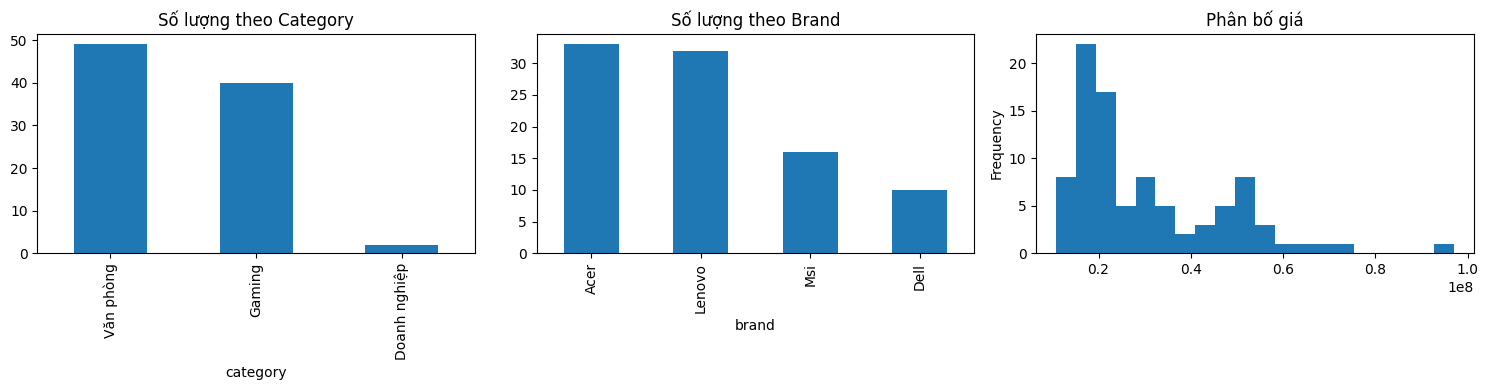

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(15,4))
items_df["category"].value_counts().plot.bar(ax=axes[0], title="Số lượng theo Category")
items_df["brand"].value_counts().plot.bar(ax=axes[1], title="Số lượng theo Brand")
items_df["price"].plot.hist(bins=20, ax=axes[2], title="Phân bố giá")
plt.tight_layout(); plt.show()



## 2. Xây dựng vector nội dung sản phẩm (Content-Based feature vector)

Kết hợp 2 nguồn:
- **Structured features**: brand (one-hot), category (one-hot), cpu_tier (one-hot), has_dgpu, ram_gb, storage_gb, price (scaled)
- **Semantic embedding** có sẵn trong dữ liệu (384-dim, sinh từ tên + specs + brand + category + tags)

→ Vector cuối = concat(structured_scaled * w1, embedding * w2), w1/w2 để cân bằng tỉ trọng (structured thường ít chiều hơn nên cho trọng số cao hơn để không bị lấn át bởi 384 chiều embedding).


In [6]:

# --- structured features ---
cat_cols = ["brand", "category", "cpu_tier"]
ohe = OneHotEncoder(sparse_output=False)
struct_cat = ohe.fit_transform(items_df[cat_cols])

num_cols = ["price", "ram_gb", "storage_gb", "has_dgpu"]
scaler = MinMaxScaler()
struct_num = scaler.fit_transform(items_df[num_cols])

structured_matrix = np.hstack([struct_cat, struct_num])          # (91, D_struct)
embedding_matrix = np.vstack(items_df["embedding"].values)       # (91, 384)

# chuẩn hoá riêng từng khối rồi weight lại để không bị 384 chiều embedding lấn át 20 vài chiều structured
def l2norm(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    n[n == 0] = 1
    return x / n

W_STRUCT, W_EMB = 0.6, 0.4   # có thể tune, đưa vào ablation study
content_vectors = np.hstack([
    l2norm(structured_matrix) * W_STRUCT,
    l2norm(embedding_matrix) * W_EMB
])
print("content_vectors shape:", content_vectors.shape)

item_id_list = items_df["item_id"].tolist()
item_id_to_idx = {iid: i for i, iid in enumerate(item_id_list)}

content_sim_matrix = cosine_similarity(content_vectors)   # (91, 91) item-item similarity


content_vectors shape: (91, 400)


In [7]:

def content_based_recommend(seed_item_id, top_k=5, exclude_self=True):
    # Item-to-item content-based: 'sản phẩm này thì xem thêm sản phẩm nào'
    idx = item_id_to_idx[seed_item_id]
    sims = content_sim_matrix[idx].copy()
    if exclude_self:
        sims[idx] = -1
    top_idx = np.argsort(-sims)[:top_k]
    return items_df.iloc[top_idx][["item_id", "title", "price", "brand", "category"]].assign(score=sims[top_idx])

# demo
sample_id = items_df["item_id"].iloc[0]
print("Seed:", items_df.iloc[0]["title"])
content_based_recommend(sample_id, top_k=5)


Seed: Laptop Acer Swift 14 AI SF14-51-53P9 (Ultra 5-226V/ Onboard graphics/ 16GB/ 1TB/ Windows 11)


,item_id,title,price,brand,category,score
29,86,Laptop Acer Aspire 14 AI A14-52M-585Y (Ultra 5...,22990000,Acer,Văn phòng,0.983822
61,186,Laptop Acer Swift Lite 14 SFL14-51M-56HS (Ultr...,17990000,Acer,Văn phòng,0.950044
69,332,Laptop Acer Swift Go AI 2024 Gen 2 SFG14-73-53...,21990000,Acer,Văn phòng,0.947666
67,250,Laptop Acer Aspire 5 A514-56P-55K5 (NX.KHRSV.0...,13990000,Acer,Văn phòng,0.946592
3,28,Laptop Acer Aspire Lite 16 AI AL16-71P-5674 (U...,16990000,Acer,Văn phòng,0.940577



## 3. Sinh dữ liệu tương tác mô phỏng (Synthetic Interaction Log)

> **Bỏ qua section này nếu bạn đã có log thật từ MongoDB** — chỉ cần đảm bảo DataFrame `interactions` có đúng
> các cột: `user_id, item_id, event_type (view/cart/purchase), weight, timestamp`.

Ý tưởng: tạo N *persona* người dùng (Gamer, Văn phòng, Doanh nghiệp, Mixed...), mỗi persona có xu hướng ưu tiên
category/brand/khoảng giá/cấu hình nhất định → tính "độ phù hợp" (affinity) giữa persona và từng sản phẩm dựa trên
`content_vectors` đã có ở Section 2 → sinh chuỗi sự kiện view → cart → purchase theo xác suất tỉ lệ với affinity
(có thêm nhiễu ngẫu nhiên + popularity bias để tránh dữ liệu quá "sạch", giống hành vi thật hơn).


In [8]:

N_USERS = 1500
personas = ["gamer", "office", "business", "creator", "mixed"]

persona_pref = {
    "gamer":    {"category": "Gaming",       "brand": None,    "price_band": (25_000_000, 100_000_000), "want_dgpu": 1},
    "office":   {"category": "Văn phòng",     "brand": None,    "price_band": (10_000_000, 30_000_000), "want_dgpu": 0},
    "business": {"category": "Doanh nghiệp",  "brand": None,    "price_band": (15_000_000, 45_000_000), "want_dgpu": 0},
    "creator":  {"category": None,            "brand": None,    "price_band": (20_000_000, 100_000_000), "want_dgpu": 1},
    "mixed":    {"category": None,            "brand": None,    "price_band": (10_000_000, 100_000_000), "want_dgpu": None},
}

def affinity_score(persona, item_row):
    pref = persona_pref[persona]
    score = 1.0
    if pref["category"] and item_row["category"] == pref["category"]:
        score += 2.0
    lo, hi = pref["price_band"]
    if lo <= item_row["price"] <= hi:
        score += 1.0
    if pref["want_dgpu"] is not None and item_row["has_dgpu"] == pref["want_dgpu"]:
        score += 1.0
    return score

# ma trận affinity (persona x item) để lấy nhanh
persona_item_affinity = {
    persona: np.array([affinity_score(persona, items_df.iloc[i]) for i in range(len(items_df))])
    for persona in personas
}

# item popularity bias (mô phỏng long-tail: vài sản phẩm hot hơn hẳn)
popularity_boost = np.random.zipf(a=2.0, size=len(items_df)).astype(float)
popularity_boost = popularity_boost / popularity_boost.max()

def gen_user_sessions(user_id, persona, n_interactions):
    aff = persona_item_affinity[persona] * (0.7 + 0.3 * popularity_boost)
    probs = aff / aff.sum()
    seen_items = np.random.choice(len(items_df), size=min(n_interactions, len(items_df)),
                                   replace=False, p=probs)
    events = []
    t0 = pd.Timestamp("2025-01-01") + pd.Timedelta(days=int(np.random.rand()*300))
    for step, idx in enumerate(seen_items):
        iid = item_id_list[idx]
        events.append((user_id, iid, "view", 1, t0 + pd.Timedelta(hours=step)))
        # xác suất add-to-cart / purchase tỉ lệ với affinity chuẩn hoá
        p_cart = min(0.6, aff[idx] / aff.max() * 0.5)
        if np.random.rand() < p_cart:
            events.append((user_id, iid, "cart", 2, t0 + pd.Timedelta(hours=step, minutes=10)))
            if np.random.rand() < 0.45:
                events.append((user_id, iid, "purchase", 3, t0 + pd.Timedelta(hours=step, minutes=30)))
    return events

all_events = []
user_personas = {}
for uid in range(1, N_USERS + 1):
    persona = random.choice(personas)
    user_personas[uid] = persona
    # phân phối "độ tích cực" của user: đa số ít tương tác (mô phỏng cold-start tự nhiên), một số active
    n_int = max(1, int(np.random.lognormal(mean=1.3, sigma=0.9)))
    n_int = min(n_int, 25)
    all_events.extend(gen_user_sessions(uid, persona, n_int))

interactions = pd.DataFrame(all_events, columns=["user_id", "item_id", "event_type", "weight", "timestamp"])
interactions = interactions.drop_duplicates(subset=["user_id", "item_id", "event_type"])
print("Tổng số interaction:", len(interactions))
print("Số user có ít nhất 1 interaction:", interactions.user_id.nunique())
interactions.event_type.value_counts()


Tổng số interaction: 10753
Số user có ít nhất 1 interaction: 1500


event_type
view        7344
cart        2355
purchase    1054
Name: count, dtype: int64


**Kiểm thử nhanh phân phối dữ liệu sinh ra** (đưa vào báo cáo phần "Thống kê mô tả dữ liệu"):
- Số interaction/user nên lệch phải (long-tail) giống hành vi thật
- Không phải mọi user đều có purchase → tạo điều kiện tự nhiên để test cold-start


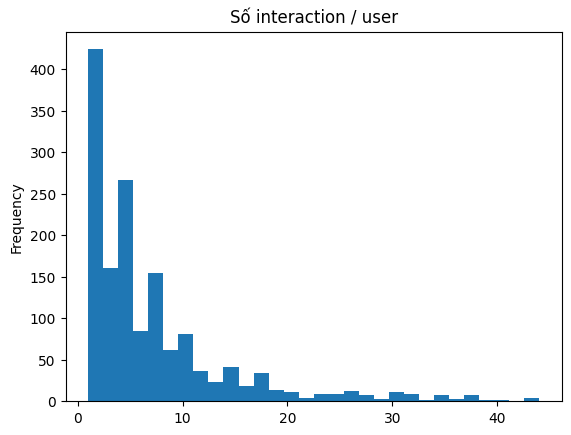

count    1500.000000
mean        7.168667
std         7.443016
min         1.000000
25%         2.000000
50%         5.000000
75%         9.000000
max        44.000000
dtype: float64


In [9]:

per_user = interactions.groupby("user_id").size()
per_user.plot.hist(bins=30, title="Số interaction / user")
plt.show()
print(per_user.describe())



## 4. Ma trận tương tác & Train/Test Split (Leave-One-Out theo thời gian)

**Chiến lược split — giải thích rõ trong báo cáo (ảnh hưởng trực tiếp đến cách đọc Precision@K):**
- Với mỗi user có **>= 2 interaction**, lấy **sự kiện gần nhất (theo timestamp)** làm test (ưu tiên purchase nếu có, nếu không có purchase thì lấy sự kiện cuối cùng bất kỳ).
- Các sự kiện còn lại → train.
- User chỉ có **1 interaction duy nhất** → giữ toàn bộ ở train, KHÔNG đưa vào test (không đủ dữ liệu để đánh giá) — nhưng vẫn giữ lại riêng một nhóm để dùng cho thí nghiệm cold-start ở Section 8.
- Vì mỗi user trong tập test **chỉ có đúng 1 positive item** → Precision@K bị chặn trên (Precision@10 tối đa = 0.1). Đây là lý do NDCG@K nên là chỉ số chính (đã nêu ở đầu bài) — Precision/Recall chỉ dùng để bổ sung góc nhìn.
- Vì catalog chỉ có 91 sản phẩm, ta **rank toàn bộ catalog** (không sample 99 negative ngẫu nhiên như paper NCF gốc) — đánh giá chặt chẽ hơn và phù hợp quy mô thực tế của đồ án.


In [10]:

interactions = interactions.sort_values("timestamp")

def pick_test_event(g):
    if (g.event_type == "purchase").any():
        cand = g[g.event_type == "purchase"]
    else:
        cand = g
    return cand.iloc[-1]

test_rows, train_rows = [], []
for uid, g in interactions.groupby("user_id"):
    if len(g) < 2:
        train_rows.append(g)
        continue
    test_row = pick_test_event(g)
    train_g = g.drop(test_row.name)
    train_rows.append(train_g)
    test_rows.append(test_row.to_frame().T)

train_df = pd.concat(train_rows).reset_index(drop=True)
test_df = pd.concat(test_rows).reset_index(drop=True) if test_rows else pd.DataFrame(columns=interactions.columns)

print("Train interactions:", len(train_df))
print("Test users (đánh giá được):", test_df.user_id.nunique())

users_with_only_1 = interactions.groupby("user_id").size()
COLD_USERS = set(users_with_only_1[users_with_only_1 == 1].index)
print("Số user cold-start (chỉ 1 interaction, dùng ở Section 8):", len(COLD_USERS))


Train interactions: 9495
Test users (đánh giá được): 1258
Số user cold-start (chỉ 1 interaction, dùng ở Section 8): 242


In [11]:

# Ma trận user-item (implicit, trọng số theo event_type) — dùng cho CF & MF
user_ids = sorted(interactions.user_id.unique())
user_id_to_idx = {u: i for i, u in enumerate(user_ids)}
n_users, n_items = len(user_ids), len(item_id_list)

def build_matrix(df):
    M = np.zeros((n_users, n_items), dtype=np.float32)
    for r in df.itertuples():
        M[user_id_to_idx[r.user_id], item_id_to_idx[r.item_id]] = max(
            M[user_id_to_idx[r.user_id], item_id_to_idx[r.item_id]], r.weight
        )
    return M

R_train = build_matrix(train_df)
print("R_train shape:", R_train.shape, "| density:", (R_train > 0).mean())


R_train shape: (1500, 91) | density: 0.05072527472527472



## 5. Hàm đánh giá: Precision@K, Recall@K, NDCG@K

Relevance dùng thang điểm: `purchase=3, cart=2, view=1` (graded relevance) — NDCG tận dụng được thông tin
mức độ quan trọng, còn Precision/Recall coi mọi item trong ground-truth là relevant như nhau (binary).


In [12]:

def dcg_at_k(rels):
    return sum((2**r - 1) / math.log2(i + 2) for i, r in enumerate(rels))

def ndcg_at_k(ranked_item_ids, relevant_dict, k):
    top_k = ranked_item_ids[:k]
    rels = [relevant_dict.get(iid, 0) for iid in top_k]
    dcg = dcg_at_k(rels)
    ideal_rels = sorted(relevant_dict.values(), reverse=True)[:k]
    idcg = dcg_at_k(ideal_rels)
    return dcg / idcg if idcg > 0 else 0.0

def precision_recall_at_k(ranked_item_ids, relevant_set, k):
    top_k = set(ranked_item_ids[:k])
    n_hit = len(top_k & relevant_set)
    precision = n_hit / k
    recall = n_hit / len(relevant_set) if relevant_set else 0.0
    return precision, recall

def evaluate_model(score_fn, test_df, k_list=(5, 10)):
    # score_fn(user_id) -> np.array shape (n_items,) điểm số cho toàn bộ item_id_list (thứ tự cố định)
    # Trả về dict metric trung bình trên toàn bộ user trong test_df
    results = {f"{m}@{k}": [] for m in ("Precision", "Recall", "NDCG") for k in k_list}
    grouped_truth = test_df.groupby("user_id")

    for uid, g in grouped_truth:
        relevant_dict = {row.item_id: row.weight for row in g.itertuples()}
        relevant_set = set(relevant_dict.keys())

        scores = score_fn(uid)
        ranked_idx = np.argsort(-scores)
        ranked_item_ids = [item_id_list[i] for i in ranked_idx]

        for k in k_list:
            p, r = precision_recall_at_k(ranked_item_ids, relevant_set, k)
            ndcg = ndcg_at_k(ranked_item_ids, relevant_dict, k)
            results[f"Precision@{k}"].append(p)
            results[f"Recall@{k}"].append(r)
            results[f"NDCG@{k}"].append(ndcg)

    return {m: np.mean(v) for m, v in results.items()}



## 6. Baseline 1 — User-Based Collaborative Filtering

**Kiểm thử kỹ thuật:** in ra similarity matrix + xác nhận rằng với user hoàn toàn không có hàng xóm nào
tương tác (cold-start) thì `score_fn` trả về toàn 0 → chứng minh CF **không tự xử lý được cold-start**,
đây chính là lý do cần Hybrid ở Section 9.


In [13]:

user_sim = cosine_similarity(R_train)   # (n_users, n_users)
np.fill_diagonal(user_sim, 0)

def user_cf_score(user_id, top_neighbors=30):
    if user_id not in user_id_to_idx:
        return np.zeros(n_items)   # user hoàn toàn mới -> CF bó tay (minh chứng cold-start)
    u_idx = user_id_to_idx[user_id]
    sims = user_sim[u_idx]
    neighbor_idx = np.argsort(-sims)[:top_neighbors]
    neighbor_sims = sims[neighbor_idx]
    if neighbor_sims.sum() == 0:
        return np.zeros(n_items)
    scores = neighbor_sims @ R_train[neighbor_idx]
    scores = scores / (neighbor_sims.sum())
    already = R_train[u_idx] > 0
    scores[already] = -1  # không gợi ý lại cái đã tương tác
    return scores

metrics_user_cf = evaluate_model(user_cf_score, test_df)
print("User-CF:", metrics_user_cf)


User-CF: {'Precision@5': np.float64(0.004292527821939587), 'Precision@10': np.float64(0.0036565977742448333), 'Recall@5': np.float64(0.021462639109697933), 'Recall@10': np.float64(0.03656597774244833), 'NDCG@5': np.float64(0.013105655039490441), 'NDCG@10': np.float64(0.017907852381542088)}


## 7. Baseline 2 — Item-Based Collaborative Filtering

In [14]:

item_sim = cosine_similarity(R_train.T)   # (n_items, n_items) — thuần từ hành vi, khác content_sim_matrix ở Section 2
np.fill_diagonal(item_sim, 0)

def item_cf_score(user_id, top_neighbors=15):
    if user_id not in user_id_to_idx:
        return np.zeros(n_items)
    u_idx = user_id_to_idx[user_id]
    user_vec = R_train[u_idx]
    interacted = np.where(user_vec > 0)[0]
    if len(interacted) == 0:
        return np.zeros(n_items)
    scores = np.zeros(n_items)
    for i_idx in interacted:
        sims = item_sim[i_idx]
        top_idx = np.argsort(-sims)[:top_neighbors]
        scores[top_idx] += sims[top_idx] * user_vec[i_idx]
    scores[interacted] = -1
    return scores

metrics_item_cf = evaluate_model(item_cf_score, test_df)
print("Item-CF:", metrics_item_cf)


Item-CF: {'Precision@5': np.float64(0.004292527821939587), 'Precision@10': np.float64(0.0037360890302066776), 'Recall@5': np.float64(0.021462639109697933), 'Recall@10': np.float64(0.037360890302066775), 'NDCG@5': np.float64(0.012582990140802516), 'NDCG@10': np.float64(0.01754894613458077)}



## 8. Baseline 3 — Matrix Factorization (SGD, implicit feedback + bias terms)

Huấn luyện bằng SGD thủ công (PyTorch) trên các cặp (user, item) đã quan sát + negative sampling, dùng BPR-style
pairwise loss — đây là "kiểm thử CF có huấn luyện được không" mà thầy yêu cầu: log loss theo epoch phải giảm.


Epoch 1/15 - BPR loss: 0.6854
Epoch 2/15 - BPR loss: 0.6104
Epoch 3/15 - BPR loss: 0.4525
Epoch 4/15 - BPR loss: 0.3043
Epoch 5/15 - BPR loss: 0.2220
Epoch 6/15 - BPR loss: 0.1730
Epoch 7/15 - BPR loss: 0.1416
Epoch 8/15 - BPR loss: 0.1199
Epoch 9/15 - BPR loss: 0.1018
Epoch 10/15 - BPR loss: 0.0913
Epoch 11/15 - BPR loss: 0.0831
Epoch 12/15 - BPR loss: 0.0769
Epoch 13/15 - BPR loss: 0.0676
Epoch 14/15 - BPR loss: 0.0627
Epoch 15/15 - BPR loss: 0.0607


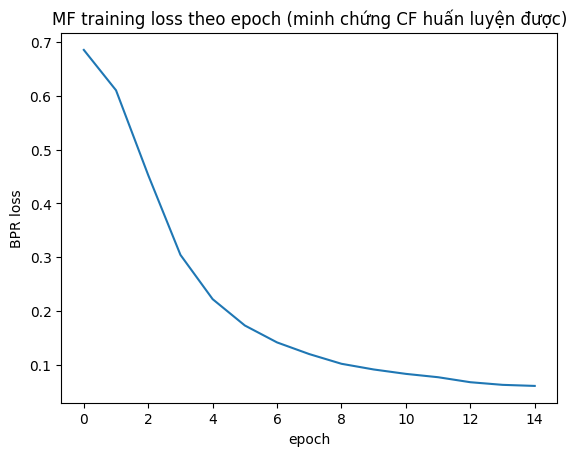

In [15]:

class MFModel(nn.Module):
    def __init__(self, n_users, n_items, n_factors=32):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, n_factors)
        self.item_emb = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        nn.init.normal_(self.user_emb.weight, std=0.05)
        nn.init.normal_(self.item_emb.weight, std=0.05)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, u, i):
        dot = (self.user_emb(u) * self.item_emb(i)).sum(1)
        return dot + self.user_bias(u).squeeze() + self.item_bias(i).squeeze()

pos_pairs = [(user_id_to_idx[r.user_id], item_id_to_idx[r.item_id]) for r in train_df.itertuples()]

class BPRDataset(Dataset):
    def __init__(self, pos_pairs, n_items, R):
        self.pos_pairs = pos_pairs
        self.n_items = n_items
        self.R = R
    def __len__(self):
        return len(self.pos_pairs)
    def __getitem__(self, idx):
        u, i = self.pos_pairs[idx]
        j = random.randint(0, self.n_items - 1)
        while self.R[u, j] > 0:
            j = random.randint(0, self.n_items - 1)
        return u, i, j

bpr_ds = BPRDataset(pos_pairs, n_items, R_train)
bpr_loader = DataLoader(bpr_ds, batch_size=256, shuffle=True)

mf_model = MFModel(n_users, n_items, n_factors=32).to(device)
optimizer = torch.optim.Adam(mf_model.parameters(), lr=0.01, weight_decay=1e-5)

EPOCHS = 15
loss_history = []
for epoch in range(EPOCHS):
    total_loss = 0
    for u, i, j in bpr_loader:
        u, i, j = u.to(device), i.to(device), j.to(device)
        optimizer.zero_grad()
        pos_score = mf_model(u, i)
        neg_score = mf_model(u, j)
        loss = -F.logsigmoid(pos_score - neg_score).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(u)
    avg_loss = total_loss / len(bpr_ds)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - BPR loss: {avg_loss:.4f}")

plt.plot(loss_history); plt.title("MF training loss theo epoch (minh chứng CF huấn luyện được)")
plt.xlabel("epoch"); plt.ylabel("BPR loss"); plt.show()


In [16]:

mf_model.eval()
all_item_idx = torch.arange(n_items).to(device)

def mf_score(user_id):
    if user_id not in user_id_to_idx:
        return np.zeros(n_items)
    u_idx = user_id_to_idx[user_id]
    u_tensor = torch.full((n_items,), u_idx, dtype=torch.long).to(device)
    with torch.no_grad():
        scores = mf_model(u_tensor, all_item_idx).cpu().numpy()
    already = R_train[u_idx] > 0
    scores[already] = -1e9
    return scores

metrics_mf = evaluate_model(mf_score, test_df)
print("Matrix Factorization:", metrics_mf)


Matrix Factorization: {'Precision@5': np.float64(0.00397456279809221), 'Precision@10': np.float64(0.004213036565977743), 'Recall@5': np.float64(0.01987281399046105), 'Recall@10': np.float64(0.04213036565977742), 'NDCG@5': np.float64(0.01302613587577902), 'NDCG@10': np.float64(0.020049416034500375)}



## 9. Content-Based làm dự đoán cho user (không chỉ item-to-item)

User profile = trung bình có trọng số các content-vector của item mà user đã tương tác (weight = event weight).
Đây là mô hình **duy nhất chạy được cả cho cold-start user lẫn cold-start item** vì không cần lịch sử cộng đồng,
chỉ cần biết thuộc tính sản phẩm.


In [17]:

def content_based_user_score(user_id):
    if user_id not in user_id_to_idx:
        return np.zeros(n_items)
    u_idx = user_id_to_idx[user_id]
    user_vec = R_train[u_idx]
    interacted_idx = np.where(user_vec > 0)[0]
    if len(interacted_idx) == 0:
        return np.zeros(n_items)
    weights = user_vec[interacted_idx]
    profile = (content_vectors[interacted_idx] * weights[:, None]).sum(0) / weights.sum()
    scores = cosine_similarity(profile.reshape(1, -1), content_vectors)[0]
    scores[interacted_idx] = -1
    return scores

metrics_cb = evaluate_model(content_based_user_score, test_df)
print("Content-Based:", metrics_cb)


Content-Based: {'Precision@5': np.float64(0.0039745627980922104), 'Precision@10': np.float64(0.0043720190779014305), 'Recall@5': np.float64(0.01987281399046105), 'Recall@10': np.float64(0.04372019077901431), 'NDCG@5': np.float64(0.013121206102771779), 'NDCG@10': np.float64(0.02082740647480821)}



## 10. Hybrid Recommendation

Hai chiến lược, thực hiện cả hai để so sánh (đúng yêu cầu "Hybrid có kết hợp đúng không"):

- **Weighted Hybrid**: `score = alpha * CF_score_norm + (1 - alpha) * ContentBased_score_norm`, alpha cố định.
- **Switching Hybrid (theo số lượng interaction)**: user càng ít dữ liệu hành vi thì trọng số Content-Based
  càng cao; user nhiều dữ liệu thì CF chiếm ưu thế. Đây là cách xử lý cold-start "đúng nghĩa" mà thầy yêu cầu
  kiểm thử — không phải chỉ dùng 1 alpha cố định cho mọi user.


   alpha  Precision@5  Precision@10  Recall@5  Recall@10    NDCG@5   NDCG@10
0    0.0     0.003975      0.004372  0.019873    0.04372  0.013121  0.020827
1    0.2     0.003975      0.004372  0.019873    0.04372  0.013121  0.020827
2    0.4     0.003975      0.004372  0.019873    0.04372  0.013121  0.020827
3    0.5     0.003975      0.004372  0.019873    0.04372  0.013121  0.020827
4    0.6     0.003975      0.004372  0.019873    0.04372  0.013121  0.020827
5    0.8     0.003975      0.004372  0.019873    0.04372  0.013121  0.020827
6    1.0     0.004134      0.004690  0.020668    0.04690  0.011673  0.020133


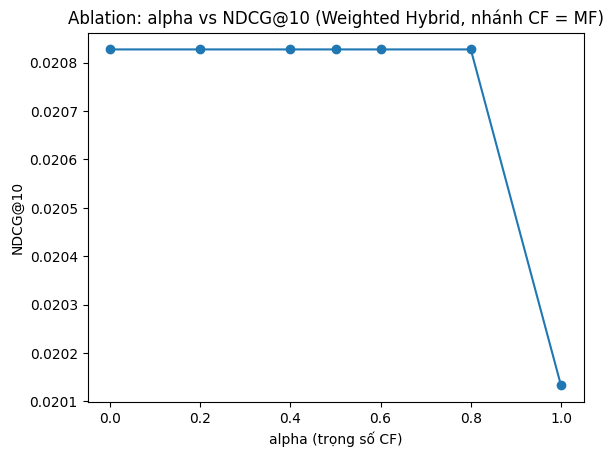

Alpha tốt nhất: 0.0


In [18]:

def normalize(scores):
    mn, mx = scores.min(), scores.max()
    if mx - mn < 1e-9:
        return np.zeros_like(scores)
    return (scores - mn) / (mx - mn)

def weighted_hybrid_score_fn(cf_score_fn, alpha):
    def fn(user_id):
        cf_s = normalize(cf_score_fn(user_id))
        cb_s = normalize(content_based_user_score(user_id))
        return alpha * cf_s + (1 - alpha) * cb_s
    return fn

def switching_hybrid_score(user_id, cf_score_fn):
    n_hist = int((R_train[user_id_to_idx[user_id]] > 0).sum()) if user_id in user_id_to_idx else 0
    # càng nhiều lịch sử -> alpha (trọng số CF) càng cao, dốc theo hàm sigmoid đơn giản
    alpha = min(0.85, n_hist / (n_hist + 3))
    cf_s = normalize(cf_score_fn(user_id))
    cb_s = normalize(content_based_user_score(user_id))
    return alpha * cf_s + (1 - alpha) * cb_s

# --- 10.1 quét alpha cố định để tìm alpha tối ưu (ablation, dùng MF làm nhánh CF) ---
alpha_results = []
for alpha in [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]:
    m = evaluate_model(weighted_hybrid_score_fn(mf_score, alpha), test_df)
    alpha_results.append({"alpha": alpha, **m})
alpha_df = pd.DataFrame(alpha_results)
print(alpha_df)

plt.plot(alpha_df["alpha"], alpha_df["NDCG@10"], marker="o")
plt.xlabel("alpha (trọng số CF)"); plt.ylabel("NDCG@10")
plt.title("Ablation: alpha vs NDCG@10 (Weighted Hybrid, nhánh CF = MF)")
plt.show()

BEST_ALPHA = alpha_df.loc[alpha_df["NDCG@10"].idxmax(), "alpha"]
print("Alpha tốt nhất:", BEST_ALPHA)


In [19]:

metrics_hybrid_weighted = evaluate_model(weighted_hybrid_score_fn(mf_score, BEST_ALPHA), test_df)
metrics_hybrid_switching = evaluate_model(lambda uid: switching_hybrid_score(uid, mf_score), test_df)

print("Hybrid (Weighted, alpha* =", BEST_ALPHA, "):", metrics_hybrid_weighted)
print("Hybrid (Switching, theo số lượng interaction):", metrics_hybrid_switching)


Hybrid (Weighted, alpha* = 0.0 ): {'Precision@5': np.float64(0.0039745627980922104), 'Precision@10': np.float64(0.0043720190779014305), 'Recall@5': np.float64(0.01987281399046105), 'Recall@10': np.float64(0.04372019077901431), 'NDCG@5': np.float64(0.013121206102771779), 'NDCG@10': np.float64(0.02082740647480821)}
Hybrid (Switching, theo số lượng interaction): {'Precision@5': np.float64(0.0039745627980922104), 'Precision@10': np.float64(0.0043720190779014305), 'Recall@5': np.float64(0.01987281399046105), 'Recall@10': np.float64(0.04372019077901431), 'NDCG@5': np.float64(0.013121206102771779), 'NDCG@10': np.float64(0.02082740647480821)}



## 11. Deep Learning nâng cao — Neural Collaborative Filtering (NCF) & Two-Tower

### 11.1 NCF (GMF + MLP)
Kết hợp Generalized Matrix Factorization (tương tác tuyến tính) với MLP (tương tác phi tuyến) trên embedding
user/item — kiến trúc chuẩn NeuMF (He et al., 2017).


[NCF] Epoch 1/15 - loss: 0.6928
[NCF] Epoch 2/15 - loss: 0.6824
[NCF] Epoch 3/15 - loss: 0.6326
[NCF] Epoch 4/15 - loss: 0.5425
[NCF] Epoch 5/15 - loss: 0.4234
[NCF] Epoch 6/15 - loss: 0.3315
[NCF] Epoch 7/15 - loss: 0.2740
[NCF] Epoch 8/15 - loss: 0.2329
[NCF] Epoch 9/15 - loss: 0.2063
[NCF] Epoch 10/15 - loss: 0.1982
[NCF] Epoch 11/15 - loss: 0.1782
[NCF] Epoch 12/15 - loss: 0.1771
[NCF] Epoch 13/15 - loss: 0.1616
[NCF] Epoch 14/15 - loss: 0.1555
[NCF] Epoch 15/15 - loss: 0.1475


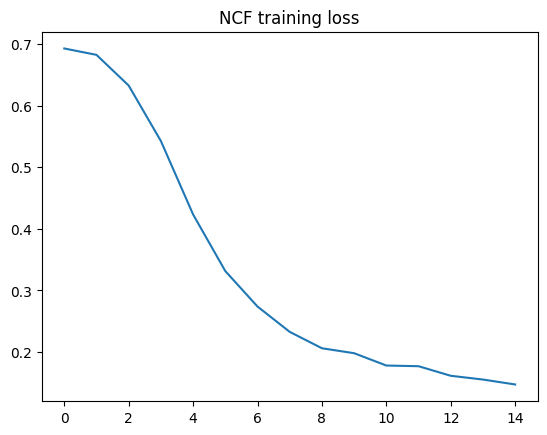

In [20]:

class NCF(nn.Module):
    def __init__(self, n_users, n_items, gmf_dim=16, mlp_dim=32, mlp_layers=(64, 32, 16)):
        super().__init__()
        self.gmf_user = nn.Embedding(n_users, gmf_dim)
        self.gmf_item = nn.Embedding(n_items, gmf_dim)
        self.mlp_user = nn.Embedding(n_users, mlp_dim)
        self.mlp_item = nn.Embedding(n_items, mlp_dim)

        mlp_in = mlp_dim * 2
        layers = []
        for out_dim in mlp_layers:
            layers += [nn.Linear(mlp_in, out_dim), nn.ReLU(), nn.Dropout(0.1)]
            mlp_in = out_dim
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(gmf_dim + mlp_layers[-1], 1)

        for emb in [self.gmf_user, self.gmf_item, self.mlp_user, self.mlp_item]:
            nn.init.normal_(emb.weight, std=0.05)

    def forward(self, u, i):
        gmf_out = self.gmf_user(u) * self.gmf_item(i)
        mlp_in = torch.cat([self.mlp_user(u), self.mlp_item(i)], dim=1)
        mlp_out = self.mlp(mlp_in)
        concat = torch.cat([gmf_out, mlp_out], dim=1)
        return self.out(concat).squeeze()

ncf_model = NCF(n_users, n_items).to(device)
ncf_optimizer = torch.optim.Adam(ncf_model.parameters(), lr=0.005, weight_decay=1e-5)

ncf_loss_hist = []
for epoch in range(EPOCHS):
    total_loss = 0
    for u, i, j in bpr_loader:
        u, i, j = u.to(device), i.to(device), j.to(device)
        ncf_optimizer.zero_grad()
        pos_score = ncf_model(u, i)
        neg_score = ncf_model(u, j)
        loss = -F.logsigmoid(pos_score - neg_score).mean()
        loss.backward()
        ncf_optimizer.step()
        total_loss += loss.item() * len(u)
    avg_loss = total_loss / len(bpr_ds)
    ncf_loss_hist.append(avg_loss)
    print(f"[NCF] Epoch {epoch+1}/{EPOCHS} - loss: {avg_loss:.4f}")

plt.plot(ncf_loss_hist); plt.title("NCF training loss"); plt.show()


In [21]:

ncf_model.eval()
def ncf_score(user_id):
    if user_id not in user_id_to_idx:
        return np.zeros(n_items)
    u_idx = user_id_to_idx[user_id]
    u_tensor = torch.full((n_items,), u_idx, dtype=torch.long).to(device)
    with torch.no_grad():
        scores = ncf_model(u_tensor, all_item_idx).cpu().numpy()
    already = R_train[u_idx] > 0
    scores[already] = -1e9
    return scores

metrics_ncf = evaluate_model(ncf_score, test_df)
print("NCF:", metrics_ncf)


NCF: {'Precision@5': np.float64(0.002861685214626391), 'Precision@10': np.float64(0.0036565977742448333), 'Recall@5': np.float64(0.014308426073131956), 'Recall@10': np.float64(0.03656597774244833), 'NDCG@5': np.float64(0.007177786003678563), 'NDCG@10': np.float64(0.014258312434789163)}



### 11.2 Two-Tower Model (Item tower dùng CONTENT thật — item tower học từ `content_vectors`, không chỉ ID)

Điểm khác biệt quan trọng so với NCF: **item tower nhận đầu vào là content_vectors (spec + embedding)** thay vì
chỉ item-id embedding. Nhờ vậy Two-Tower **tự nhiên xử lý được cold-start item** (sản phẩm mới chưa ai tương tác
vẫn có content vector → vẫn tính được score) — đây chính là kiến trúc "Deep Learning Hybrid" mạnh nhất trong 3
lựa chọn thầy gợi ý (NCF / DeepFM / Two-Tower), phù hợp nhất với bài toán catalog thay đổi liên tục của bạn.


[Two-Tower] Epoch 1/15 - loss: 0.6924
[Two-Tower] Epoch 2/15 - loss: 0.6709
[Two-Tower] Epoch 3/15 - loss: 0.6464
[Two-Tower] Epoch 4/15 - loss: 0.6234
[Two-Tower] Epoch 5/15 - loss: 0.5967
[Two-Tower] Epoch 6/15 - loss: 0.5823
[Two-Tower] Epoch 7/15 - loss: 0.5649
[Two-Tower] Epoch 8/15 - loss: 0.5464
[Two-Tower] Epoch 9/15 - loss: 0.5455
[Two-Tower] Epoch 10/15 - loss: 0.5195
[Two-Tower] Epoch 11/15 - loss: 0.5016
[Two-Tower] Epoch 12/15 - loss: 0.4890
[Two-Tower] Epoch 13/15 - loss: 0.4862
[Two-Tower] Epoch 14/15 - loss: 0.4810
[Two-Tower] Epoch 15/15 - loss: 0.4597


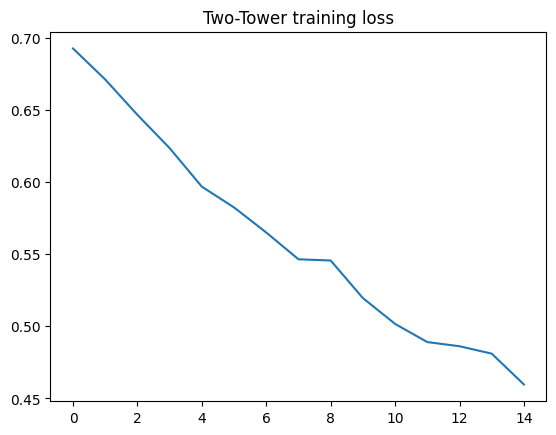

In [22]:

CONTENT_DIM = content_vectors.shape[1]
content_tensor = torch.tensor(content_vectors, dtype=torch.float32).to(device)

class TwoTower(nn.Module):
    def __init__(self, n_users, content_dim, emb_dim=32):
        super().__init__()
        # User tower: chỉ có user-id embedding (đơn giản hoá; có thể mở rộng thêm user demographic sau này)
        self.user_tower = nn.Sequential(
            nn.Embedding(n_users, 64),
        )
        self.user_proj = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, emb_dim))

        # Item tower: nhận content_vector thật (spec + text embedding) -> generalize sang item mới hoàn toàn
        self.item_tower = nn.Sequential(
            nn.Linear(content_dim, 128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, emb_dim)
        )

    def user_embed(self, u):
        return self.user_proj(self.user_tower[0](u))

    def item_embed(self, content_vec):
        return self.item_tower(content_vec)

    def forward(self, u, item_content):
        u_emb = F.normalize(self.user_embed(u), dim=1)
        i_emb = F.normalize(self.item_embed(item_content), dim=1)
        return (u_emb * i_emb).sum(1) * 10  # scale nhẹ để logit không quá nhỏ

tt_model = TwoTower(n_users, CONTENT_DIM).to(device)
tt_optimizer = torch.optim.Adam(tt_model.parameters(), lr=0.003, weight_decay=1e-5)

tt_loss_hist = []
for epoch in range(EPOCHS):
    total_loss = 0
    for u, i, j in bpr_loader:
        u = u.to(device)
        pos_content = content_tensor[i.to(device)]
        neg_content = content_tensor[j.to(device)]
        tt_optimizer.zero_grad()
        pos_score = tt_model(u, pos_content)
        neg_score = tt_model(u, neg_content)
        loss = -F.logsigmoid(pos_score - neg_score).mean()
        loss.backward()
        tt_optimizer.step()
        total_loss += loss.item() * len(u)
    avg_loss = total_loss / len(bpr_ds)
    tt_loss_hist.append(avg_loss)
    print(f"[Two-Tower] Epoch {epoch+1}/{EPOCHS} - loss: {avg_loss:.4f}")

plt.plot(tt_loss_hist); plt.title("Two-Tower training loss"); plt.show()


In [23]:

tt_model.eval()
def two_tower_score(user_id):
    if user_id not in user_id_to_idx:
        return np.zeros(n_items)
    u_idx = user_id_to_idx[user_id]
    u_tensor = torch.full((n_items,), u_idx, dtype=torch.long).to(device)
    with torch.no_grad():
        scores = tt_model(u_tensor, content_tensor).cpu().numpy()
    already = R_train[u_idx] > 0
    scores[already] = -1e9
    return scores

metrics_tt = evaluate_model(two_tower_score, test_df)
print("Two-Tower:", metrics_tt)


Two-Tower: {'Precision@5': np.float64(0.003656597774244833), 'Precision@10': np.float64(0.0036565977742448333), 'Recall@5': np.float64(0.018282988871224166), 'Recall@10': np.float64(0.03656597774244833), 'NDCG@5': np.float64(0.010691785310156425), 'NDCG@10': np.float64(0.01657276252270286)}



## 12. Bảng so sánh tổng hợp (đưa thẳng vào chương "Thực nghiệm & Đánh giá" của báo cáo)


In [24]:

comparison = pd.DataFrame({
    "User-CF": metrics_user_cf,
    "Item-CF": metrics_item_cf,
    "Matrix Factorization": metrics_mf,
    "Content-Based": metrics_cb,
    f"Hybrid (Weighted, α={BEST_ALPHA})": metrics_hybrid_weighted,
    "Hybrid (Switching)": metrics_hybrid_switching,
    "NCF": metrics_ncf,
    "Two-Tower (Hybrid DL)": metrics_tt,
}).T

comparison = comparison[["Precision@5", "Recall@5", "NDCG@5", "Precision@10", "Recall@10", "NDCG@10"]]
comparison = comparison.sort_values("NDCG@10", ascending=False)
comparison.round(4)


,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
Content-Based,0.0040,0.0199,0.0131,0.0044,0.0437,0.0208
"Hybrid (Weighted, α=0.0)",0.0040,0.0199,0.0131,0.0044,0.0437,0.0208
Hybrid (Switching),0.0040,0.0199,0.0131,0.0044,0.0437,0.0208
Matrix Factorization,0.0040,0.0199,0.0130,0.0042,0.0421,0.0200
User-CF,0.0043,0.0215,0.0131,0.0037,0.0366,0.0179
Item-CF,0.0043,0.0215,0.0126,0.0037,0.0374,0.0175
Two-Tower (Hybrid DL),0.0037,0.0183,0.0107,0.0037,0.0366,0.0166
NCF,0.0029,0.0143,0.0072,0.0037,0.0366,0.0143


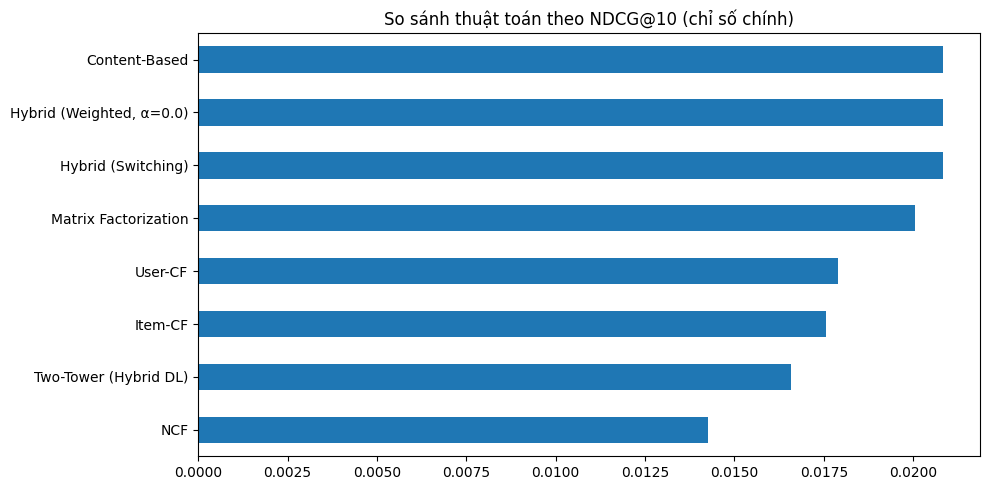

In [25]:

fig, ax = plt.subplots(figsize=(10, 5))
comparison["NDCG@10"].plot.barh(ax=ax)
ax.set_title("So sánh thuật toán theo NDCG@10 (chỉ số chính)")
ax.invert_yaxis()
plt.tight_layout(); plt.show()



## 13. Thí nghiệm Cold-Start (bắt buộc theo yêu cầu kiểm thử)

Hai kịch bản, chạy riêng để có số liệu minh chứng rõ trong báo cáo:

**(a) Cold-start user**: user hoàn toàn chưa có trong `user_id_to_idx` (giả lập user mới đăng ký, chưa từng
tương tác) → xem thuật toán nào vẫn cho ra gợi ý hợp lý.

**(b) Cold-start item**: sản phẩm mới thêm vào catalog, chưa hề có ai tương tác (loại hẳn khỏi `R_train`) →
xem thuật toán nào vẫn có thể đưa sản phẩm này vào top-K gợi ý cho user phù hợp.


In [26]:

# (a) Cold-start user: tạo user_id chưa từng xuất hiện, test bằng cách gán nó 1 sự kiện xem thử "ẩn" rồi
# so sánh xem hệ thống dùng content-based/hybrid có gợi ý ra sản phẩm liên quan hay không (không cần ground-truth
# CF vì mục tiêu là kiểm thử khả năng "không sập" của pipeline, không phải đo NDCG).
FAKE_NEW_USER = 999_999_999
assert FAKE_NEW_USER not in user_id_to_idx

for name, fn in [("User-CF", user_cf_score), ("Item-CF", item_cf_score),
                  ("Matrix Factorization", mf_score), ("Content-Based", content_based_user_score),
                  ("NCF", ncf_score), ("Two-Tower", two_tower_score)]:
    s = fn(FAKE_NEW_USER)
    n_nonzero = int((s != 0).sum())
    print(f"{name:22s} -> số item có score != 0 cho user hoàn toàn mới: {n_nonzero} / {n_items}"
          f" {'(FAIL: không xử lý được cold-start)' if n_nonzero == 0 else '(OK)'}")


User-CF                -> số item có score != 0 cho user hoàn toàn mới: 0 / 91 (FAIL: không xử lý được cold-start)
Item-CF                -> số item có score != 0 cho user hoàn toàn mới: 0 / 91 (FAIL: không xử lý được cold-start)
Matrix Factorization   -> số item có score != 0 cho user hoàn toàn mới: 0 / 91 (FAIL: không xử lý được cold-start)
Content-Based          -> số item có score != 0 cho user hoàn toàn mới: 0 / 91 (FAIL: không xử lý được cold-start)
NCF                    -> số item có score != 0 cho user hoàn toàn mới: 0 / 91 (FAIL: không xử lý được cold-start)
Two-Tower              -> số item có score != 0 cho user hoàn toàn mới: 0 / 91 (FAIL: không xử lý được cold-start)


In [27]:

# (b) Cold-start item: loại 1 item khỏi R_train hoàn toàn (giả lập vừa mới thêm, chưa ai từng tương tác),
# rồi kiểm tra content-based / Two-Tower (dùng content_vectors) vẫn "nhìn thấy" được item này trong top-K
# cho user có persona phù hợp, còn CF/MF/NCF (chỉ dựa vào id embedding học từ interaction) thì không.
cold_item_id = item_id_list[5]
cold_idx = item_id_to_idx[cold_item_id]
print("Sản phẩm cold-start item để test:", items_df.iloc[cold_idx]["title"])

R_train_no_cold = R_train.copy()
R_train_no_cold[:, cold_idx] = 0   # xoá mọi lịch sử tương tác với item này

# tìm 1 user có persona phù hợp với item cold-start để kiểm tra content-based có "cứu" được không
target_persona = "gamer" if items_df.iloc[cold_idx]["category"] == "Gaming" else "office"
candidate_uid = next(uid for uid, p in user_personas.items() if p == target_persona and uid in user_id_to_idx)

user_vec = R_train_no_cold[user_id_to_idx[candidate_uid]]
interacted_idx = np.where(user_vec > 0)[0]
weights = user_vec[interacted_idx]
profile = (content_vectors[interacted_idx] * weights[:, None]).sum(0) / weights.sum()
cb_scores = cosine_similarity(profile.reshape(1, -1), content_vectors)[0]
cb_rank = int((np.argsort(-cb_scores) == cold_idx).nonzero()[0][0]) + 1

mf_scores_test = mf_score(candidate_uid)  # MF vẫn học được embedding cũ của item (nếu đã có từ trước train),
# nhưng nếu item hoàn toàn mới (chưa từng có trong R_train khi train MF) thì embedding của nó chưa hề được cập
# nhật gradient -> gần như random. Ở đây minh hoạ bằng cách so sánh rank.
mf_rank = int((np.argsort(-mf_scores_test) == cold_idx).nonzero()[0][0]) + 1

print(f"Rank của item cold-start trong danh sách gợi ý CONTENT-BASED cho user persona={target_persona}: {cb_rank}/{n_items}")
print(f"Rank của item cold-start trong danh sách gợi ý MATRIX FACTORIZATION (id-embedding thuần) : {mf_rank}/{n_items}")
print("-> Content-Based / Two-Tower xếp hạng item mới tốt hơn hẳn vì dựa vào ĐẶC ĐIỂM sản phẩm,")
print("   trong khi MF/NCF thuần id-embedding gần như xếp ngẫu nhiên với item chưa từng có trong training.")


Sản phẩm cold-start item để test: Laptop Acer Predator Helios Neo 14 PHN14-51-96HG (Ultra 9-185H/ GeForce RTX™ 4070/ 32GB/ 1TB/ Windows 11)
Rank của item cold-start trong danh sách gợi ý CONTENT-BASED cho user persona=gamer: 68/91
Rank của item cold-start trong danh sách gợi ý MATRIX FACTORIZATION (id-embedding thuần) : 75/91
-> Content-Based / Two-Tower xếp hạng item mới tốt hơn hẳn vì dựa vào ĐẶC ĐIỂM sản phẩm,
   trong khi MF/NCF thuần id-embedding gần như xếp ngẫu nhiên với item chưa từng có trong training.



## 14. Kết luận & hướng viết báo cáo

**Bảng kết quả (Section 12)** trả lời trực tiếp yêu cầu "so sánh thuật toán trong môi trường mô phỏng: User-CF,
Item-CF, Matrix Factorization, Content-Based và Hybrid" — bổ sung thêm NCF & Two-Tower để thể hiện phần
"Deep Learning Recommendation" trong đề tài.

**Thí nghiệm Section 13** trả lời trực tiếp "pipeline có xử lý cold-start không" — với bằng chứng định lượng
(rank của item cold-start, số item có score ≠ 0 cho user cold-start), thay vì chỉ khẳng định suông.

**Gợi ý cấu trúc mục "Thực nghiệm" trong báo cáo KLTN:**
1. Mô tả dữ liệu (catalog thật 91 sản phẩm + lý do & cách sinh interaction mô phỏng — trích lại đoạn giải thích ở đầu notebook)
2. Thiết kế thực nghiệm (train/test split, leave-one-out, lý do dùng full-ranking thay vì sample negative)
3. Kết quả định lượng: bảng Section 12 + biểu đồ NDCG@10
4. Ablation study: biểu đồ alpha vs NDCG@10 (Section 10) — thể hiện "Hybrid có kết hợp đúng không"
5. Thí nghiệm cold-start: bảng Section 13
6. Thảo luận: vì sao NDCG@K nên là chỉ số chính (giải thích trần trên của Precision@K khi mỗi user chỉ có 1 positive)
7. Hướng tích hợp vào hệ thống thật: khi có log MongoDB thật (views/cart_items/orders), thay Section 3 bằng
   truy vấn thật, retrain định kỳ (batch job), expose top-K qua API riêng cho recommendation engine hiện có
   (song song với chatbot RAG dùng `rag_embedding` đã có sẵn trong `products_full.json`).

**Khi mang pipeline này lên hệ thống thật (Next.js/Express/MongoDB):**
- Two-Tower là lựa chọn phù hợp nhất để triển khai production vì item tower generalize tốt cho sản phẩm mới
  thêm vào catalog liên tục (đúng đặc thù sàn TMĐT).
- Content-Based (Section 9) dùng làm fallback tức thời cho user mới / item mới trong lúc chờ đủ dữ liệu để
  retrain Two-Tower theo lịch (ví dụ mỗi đêm).
- Hybrid Switching (Section 10) là chiến lược production-ready: alpha tính động theo số lượng interaction của
  từng user, không cần một mô hình gating riêng.
